# Figure 3 â€” SMI Development Over Days

**Panel A** â€” Median SMI per layer per day (mean Â± SEM across animals)

In [191]:
import os, re, glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
import h5py
import matplotlib as mpl

# â”€â”€ Font â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
mpl.rcParams['font.family']      = 'Arial'
mpl.rcParams['font.weight']      = 'normal'
mpl.rcParams['axes.titleweight'] = 'normal'
mpl.rcParams['axes.labelweight'] = 'normal'

# â”€â”€ CONFIG â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
PARENT_DIR   = r'D:\V1_SpatialModulation\2p\V1_prism'
LAYER_ORDER  = ['L2/3', 'L4', 'L5', 'L6']
LAYER_COLORS = {'L2/3': '#1E88E5', 'L4': '#FF9800', 'L5': '#4CAF50', 'L6': '#E53935'}
LANDMARKS    = {32: 'LD1', 60: 'LD2', 88: 'LD3', 116: 'LD4'}
MAX_DAY      = 7

OUTPUT_DIR = os.path.join(os.path.dirname(os.path.abspath('')), 'labmeeting_260420', 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Config loaded.')

Config loaded.


In [192]:
# Load SMI for every animal Ã— day Ã— layer
# smi_by_animal[animal][day][layer] = np.array of SMI values

def extract_animal_day(filepath):
    m_a = re.search(r'(JSY\d+)', filepath)
    m_d = re.search(r'[Dd]ay(\d+)', filepath)
    return (m_a.group(1) if m_a else None,
            int(m_d.group(1)) if m_d else None)

smi_files = glob.glob(os.path.join(PARENT_DIR, '**', '*_smi_results.h5'), recursive=True)

smi_by_animal = {}   # animal â†’ day â†’ layer â†’ np.array

for path in smi_files:
    animal, day = extract_animal_day(path)
    if animal is None or day is None or day > MAX_DAY:
        continue

    if animal not in smi_by_animal:
        smi_by_animal[animal] = {}
    if day not in smi_by_animal[animal]:
        smi_by_animal[animal][day] = {}

    with h5py.File(path, 'r') as f:
        for lk in f['layer_smi'].keys():
            lg         = f['layer_smi'][lk]
            layer_name = lg.attrs.get('original_name', lk.replace('_', '/'))
            if layer_name not in LAYER_ORDER:
                continue
            smi = lg['SMI'][:] if 'SMI' in lg else np.array([])
            if len(smi) > 0:
                smi_by_animal[animal][day][layer_name] = smi

animals = sorted(smi_by_animal.keys())
all_days = sorted({d for a in smi_by_animal.values() for d in a.keys()})
print(f'Animals: {animals}')
print(f'Days found: {all_days}')
print()
for animal in animals:
    days_a = sorted(smi_by_animal[animal].keys())
    print(f'  {animal}: days {days_a}')

Animals: ['JSY040', 'JSY041', 'JSY044', 'JSY051', 'JSY052', 'JSY054', 'JSY055']
Days found: [1, 2, 3, 4, 5, 6, 7]

  JSY040: days [1, 3]
  JSY041: days [1, 3, 5, 7]
  JSY044: days [1, 2, 3, 4, 5, 6, 7]
  JSY051: days [1, 2, 3, 4, 5]
  JSY052: days [1, 2, 3, 4, 5, 6, 7]
  JSY054: days [1, 2, 3, 4, 5, 6, 7]
  JSY055: days [1, 2, 3, 4, 5, 6, 7]


In [193]:
# â”€â”€ Animal selection â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Run the load cell first to see which animals are available, then edit this
# list to keep only the ones you want. Set to None to include all.

# INCLUDE_ANIMALS = ['JSY041','JSY044','JSY051','JSY052', 'JSY054','JSY055']
INCLUDE_ANIMALS = ['JSY040','JSY051','JSY052', 'JSY054','JSY055']

# â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
if INCLUDE_ANIMALS is not None:
    excluded = [a for a in animals if a not in INCLUDE_ANIMALS]
    animals  = [a for a in animals if a in INCLUDE_ANIMALS]
    for a in excluded:
        smi_by_animal.pop(a, None)
    print(f'Using animals : {animals}')
    print(f'Excluded      : {excluded}')
else:
    print(f'Using all animals: {animals}')

Using animals : ['JSY040', 'JSY051', 'JSY052', 'JSY054', 'JSY055']
Excluded      : ['JSY041', 'JSY044']


In [194]:
# Per-animal median SMI â€” printed as a table for each layer
import pandas as pd

for layer in LAYER_ORDER:
    rows = {}
    for animal in animals:
        row = {}
        for day in all_days:
            if day in smi_by_animal.get(animal, {}) and layer in smi_by_animal[animal][day]:
                row[f'Day {day}'] = round(np.median(smi_by_animal[animal][day][layer]), 3)
            else:
                row[f'Day {day}'] = np.nan
        rows[animal] = row

    df = pd.DataFrame(rows).T
    df.index.name = 'Animal'
    print(f'\nâ”€â”€ {layer} â”€â”€')
    print(df.to_string())


â”€â”€ L2/3 â”€â”€
        Day 1  Day 2  Day 3  Day 4  Day 5  Day 6  Day 7
Animal                                                 
JSY040  0.385    NaN  0.353    NaN    NaN    NaN    NaN
JSY051  0.545  0.351  0.543  0.555  0.821    NaN    NaN
JSY052  0.398  0.437  0.440  0.531  0.426  0.592  0.812
JSY054  0.552  0.474  0.564  0.548  0.577  0.611  0.410
JSY055  0.350  0.584  0.224  0.721  0.537  0.597  0.637

â”€â”€ L4 â”€â”€
        Day 1  Day 2  Day 3  Day 4  Day 5  Day 6  Day 7
Animal                                                 
JSY040  0.335    NaN  0.512    NaN    NaN    NaN    NaN
JSY051  0.497  0.424  0.688  0.502  0.682    NaN    NaN
JSY052  0.395  0.506  0.452  0.598  0.481  0.621  0.678
JSY054  0.596  0.519  0.567  0.564  0.602  0.579  0.490
JSY055  0.430  0.609  0.293  0.649  0.625  0.707  0.652

â”€â”€ L5 â”€â”€
        Day 1  Day 2  Day 3  Day 4  Day 5  Day 6  Day 7
Animal                                                 
JSY040  0.433    NaN  0.626    NaN    NaN    NaN

Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\labmeeting_260420\output\figure3_panel_A_SMI_development.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\labmeeting_260420\output\figure3_panel_A_SMI_development.png


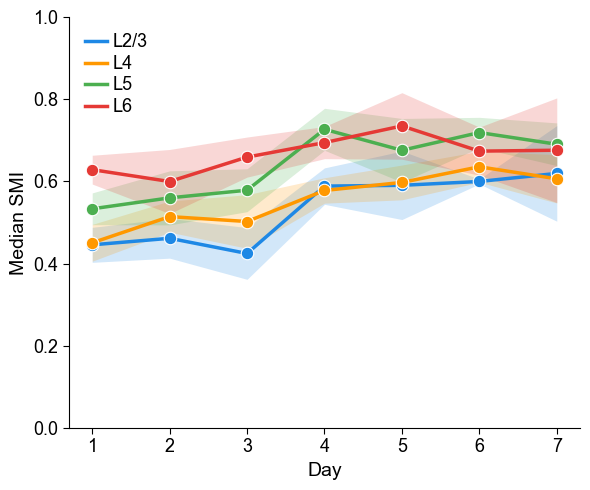

In [195]:
# Panel A — SMI development: mean ± SEM of per-animal medians
# Individual animal values shown as small dots behind mean line

animal_medians = {l: {d: [] for d in all_days} for l in LAYER_ORDER}
# Also store which animal each value belongs to for per-animal traces
animal_median_by_id = {l: {animal: {} for animal in animals} for l in LAYER_ORDER}

for animal in animals:
    for day in all_days:
        if day not in smi_by_animal[animal]:
            continue
        for layer in LAYER_ORDER:
            if layer in smi_by_animal[animal][day]:
                med = np.median(smi_by_animal[animal][day][layer])
                animal_medians[layer][day].append(med)
                animal_median_by_id[layer][animal][day] = med

# ── Plot ──────────────────────────────────────────────────────────────────────
fig_a, ax = plt.subplots(figsize=(6, 5))

for layer in LAYER_ORDER:
    color = LAYER_COLORS[layer]

    # # Individual animal traces (thin lines + small dots)
    # for animal in animals:
    #     ad = animal_median_by_id[layer][animal]
    #     if not ad:
    #         continue
    #     axs = sorted(ad.keys())
    #     ays = [ad[d] for d in axs]
    #     ax.plot(axs, ays, color=color, lw=0.8, alpha=0.3, zorder=1)
    #     ax.scatter(axs, ays, color=color, s=3**2, alpha=0.4, zorder=2)

    # Mean ± SEM across animals
    xs, ys, errs = [], [], []
    for day in all_days:
        vals = animal_medians[layer][day]
        if len(vals) < 2:
            continue
        xs.append(day)
        ys.append(np.mean(vals))
        errs.append(stats.sem(vals))

    xs   = np.array(xs)
    ys   = np.array(ys)
    errs = np.array(errs)

    ax.fill_between(xs, ys - errs, ys + errs, color=color, alpha=0.20, lw=0, zorder=3)
    ax.plot(xs, ys, color=color, lw=2.5, zorder=4, label=layer)
    ax.scatter(xs, ys, color=color, s=9**2, zorder=5,
               edgecolors='white', linewidths=0.8)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlabel('Day', fontsize=14)
ax.set_ylabel('Median SMI', fontsize=14)
ax.set_xticks(all_days)
ax.set_xlim(all_days[0] - 0.3, all_days[-1] + 0.3)
ax.set_ylim(0.0, 1.0)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.tick_params(axis='both', labelsize=13, length=4, width=0.8)

ax.set_axisbelow(True)

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(0.8)

ax.legend(fontsize=13, frameon=False, loc='upper left',
          handlelength=1.2, handletextpad=0.3, labelspacing=0.2)

plt.tight_layout()
for ext in ('.svg', '.png'):
    out = os.path.join(OUTPUT_DIR, f'figure3_panel_A_SMI_development{ext}')
    fig_a.savefig(out, dpi=300, bbox_inches='tight', format=ext.lstrip('.'))
    print(f'Saved: {out}')
plt.show()


Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\labmeeting_260420\output\figure3_panel_A0_day1_violin.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\labmeeting_260420\output\figure3_panel_A0_day1_violin.png


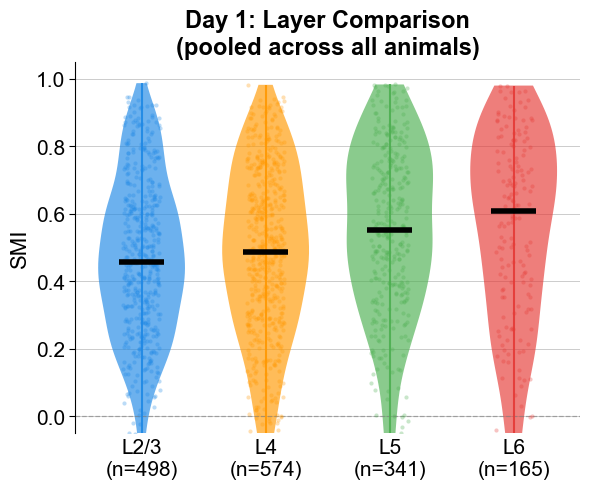

In [196]:
# Panel A0 — Day 1 violin plot: SMI distribution per layer, pooled across animals

TARGET_DAY = 1

layer_data = []
layer_ns   = []
for layer in LAYER_ORDER:
    vals = []
    for animal in animals:
        if TARGET_DAY in smi_by_animal[animal] and layer in smi_by_animal[animal][TARGET_DAY]:
            vals.extend(smi_by_animal[animal][TARGET_DAY][layer].tolist())
    layer_data.append(np.array(vals))
    layer_ns.append(len(vals))

fig_v, ax = plt.subplots(figsize=(6, 5))

rng = np.random.default_rng(42)

for i, (layer, data, n) in enumerate(zip(LAYER_ORDER, layer_data, layer_ns)):
    color = LAYER_COLORS[layer]
    x = i + 1

    if len(data) < 4:
        continue

    # Violin body
    parts = ax.violinplot(data, positions=[x], widths=0.7,
                          showmeans=False, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.65)
        pc.set_edgecolor('none')

    # Thin colored vertical line spanning full range
    ax.vlines(x, data.min(), data.max(), color=color, lw=1.5, alpha=0.9, zorder=3)

    # Thick black median line
    med = np.median(data)
    ax.hlines(med, x - 0.18, x + 0.18, color='black', lw=4, zorder=5)

    # Jittered individual dots
    jitter = rng.uniform(-0.15, 0.15, size=len(data))
    ax.scatter(x + jitter, data, color=color, s=3**2, alpha=0.3, zorder=2, linewidths=0)

ax.axhline(0, color='gray', lw=0.9, ls='--', alpha=0.6, zorder=1)

ax.set_xticks(range(1, len(LAYER_ORDER) + 1))
ax.set_xticklabels(
    [f'{l}\n(n={n})' for l, n in zip(LAYER_ORDER, layer_ns)],
    fontsize=15, color='black'
)

ax.set_ylabel('SMI', fontsize=16)
ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.tick_params(axis='y', labelsize=15, length=4, width=0.8)
ax.tick_params(axis='x', length=0)

ax.yaxis.grid(True, color='#CCCCCC', lw=0.7, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines['left'].set_linewidth(0.8)

ax.set_title(f'Day {TARGET_DAY}: Layer Comparison\n(pooled across all animals)',
             fontsize=17, fontweight='bold')

plt.tight_layout()
for ext in ('.svg', '.png'):
    out = os.path.join(OUTPUT_DIR, f'figure3_panel_A0_day1_violin{ext}')
    fig_v.savefig(out, dpi=300, bbox_inches='tight', format=ext.lstrip('.'))
    print(f'Saved: {out}')
plt.show()

Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\labmeeting_260420\output\panel_B_SMI_heatmap.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\labmeeting_260420\output\panel_B_SMI_heatmap.png


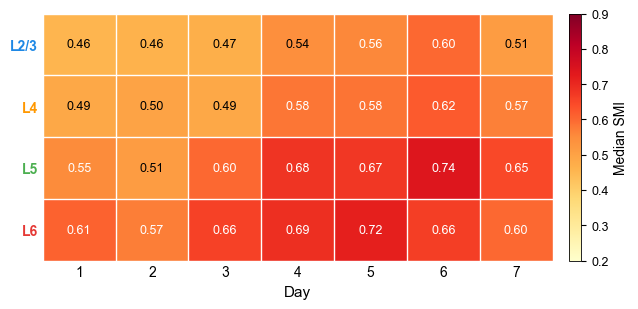

In [197]:
# Panel B — Median SMI by Layer × Day heatmap
# 4×7 matrix: pooled across all animals, overall median per cell

# Build 4×7 matrix: row=layer, col=day; pool all animals then take median
heatmap_matrix = np.full((len(LAYER_ORDER), len(all_days)), np.nan)
heatmap_annot  = [[''] * len(all_days) for _ in LAYER_ORDER]

for li, layer in enumerate(LAYER_ORDER):
    for di, day in enumerate(all_days):
        vals = []
        for animal in animals:
            if day in smi_by_animal[animal] and layer in smi_by_animal[animal][day]:
                vals.extend(smi_by_animal[animal][day][layer])
        if vals:
            med = np.median(vals)
            heatmap_matrix[li, di] = med
            heatmap_annot[li][di]  = f'{med:.2f}'

fig_b, ax = plt.subplots(figsize=(6.5, 3.2))

im = ax.imshow(heatmap_matrix, cmap='YlOrRd', vmin=0.2, vmax=0.9,
               aspect='auto', interpolation='nearest')

# Annotate cells
for li in range(len(LAYER_ORDER)):
    for di in range(len(all_days)):
        txt = heatmap_annot[li][di]
        if txt:
            val = heatmap_matrix[li, di]
            fc  = 'white' if val > 0.55 else 'black'
            ax.text(di, li, txt, ha='center', va='center',
                    fontsize=9, color=fc, fontfamily='Arial')

# Grid lines between cells
for x in np.arange(-0.5, len(all_days), 1):
    ax.axvline(x, color='white', lw=1.0)
for y in np.arange(-0.5, len(LAYER_ORDER), 1):
    ax.axhline(y, color='white', lw=1.0)

ax.set_xticks(range(len(all_days)))
ax.set_xticklabels([str(d) for d in all_days], fontsize=10)
ax.set_yticks(range(len(LAYER_ORDER)))
ax.set_yticklabels(LAYER_ORDER, fontsize=10)
for tick, layer in zip(ax.get_yticklabels(), LAYER_ORDER):
    tick.set_color(LAYER_COLORS[layer])
    tick.set_fontweight('bold')

ax.set_xlabel('Day', fontsize=11)
ax.tick_params(axis='both', length=0, width=0)

cbar = fig_b.colorbar(im, ax=ax, fraction=0.04, pad=0.03, aspect=20)
cbar.set_label('Median SMI', fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_linewidth(0.6)

ax.spines[:].set_visible(False)

plt.tight_layout()
for ext in ('.svg', '.png'):
    out = os.path.join(OUTPUT_DIR, f'panel_B_SMI_heatmap{ext}')
    fig_b.savefig(out, dpi=300, bbox_inches='tight', format=ext.lstrip('.'))
    print(f'Saved: {out}')
plt.show()

Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\labmeeting_260420\output\figure3_panel_C_sup_vs_deep.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\labmeeting_260420\output\figure3_panel_C_sup_vs_deep.png


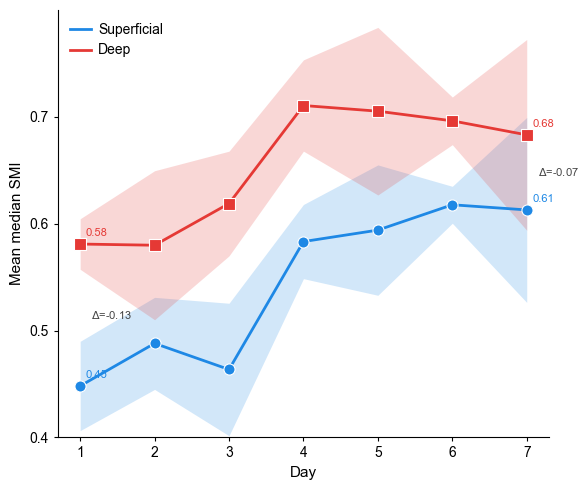

In [198]:
# Panel C â€” Superficial vs Deep two-line plot
# Per-animal daily values shown as small dots; mean Â± SEM as bold line

SUP_COLOR  = '#1E88E5'   # blue
DEEP_COLOR = '#E53935'   # red

sup_by_day   = {d: [] for d in all_days}   # list of per-animal values per day
deep_by_day  = {d: [] for d in all_days}
sup_by_animal  = {a: {} for a in animals}   # animal â†’ day â†’ value (for traces)
deep_by_animal = {a: {} for a in animals}

for animal in animals:
    for day in all_days:
        if day not in smi_by_animal[animal]:
            continue
        ad = smi_by_animal[animal][day]

        sup_meds  = [np.median(ad[l]) for l in ['L2/3', 'L4'] if l in ad]
        deep_meds = [np.median(ad[l]) for l in ['L5',  'L6']  if l in ad]

        if sup_meds:
            val = np.mean(sup_meds)
            sup_by_day[day].append(val)
            sup_by_animal[animal][day] = val
        if deep_meds:
            val = np.mean(deep_meds)
            deep_by_day[day].append(val)
            deep_by_animal[animal][day] = val

fig_c, ax = plt.subplots(figsize=(6, 5))

for label, color, by_day, by_animal_d, marker in [
    ('Superficial', SUP_COLOR,  sup_by_day,  sup_by_animal,  'o'),
    ('Deep',        DEEP_COLOR, deep_by_day, deep_by_animal, 's'),
]:
    # # Individual animal traces
    # for animal in animals:
    #     ad = by_animal_d[animal]
    #     if not ad:
    #         continue
    #     axs = sorted(ad.keys())
    #     ays = [ad[d] for d in axs]
    #     ax.plot(axs, ays, color=color, lw=0.8, alpha=0.3, zorder=1)
    #     ax.scatter(axs, ays, color=color, s=3**2, alpha=0.4, zorder=2, marker=marker)

    # Mean Â± SEM
    xs, ys, errs = [], [], []
    for day in all_days:
        vals = by_day[day]
        if len(vals) < 2:
            continue
        xs.append(day)
        ys.append(np.mean(vals))
        errs.append(stats.sem(vals))
    xs   = np.array(xs)
    ys   = np.array(ys)
    errs = np.array(errs)

    ax.fill_between(xs, ys - errs, ys + errs, color=color, alpha=0.20, lw=0, zorder=3)
    ax.plot(xs, ys, color=color, lw=2, zorder=4, label=label)
    ax.scatter(xs, ys, color=color, s=8**2, marker=marker, zorder=5,
               edgecolors='white', linewidths=0.8)

    # Annotate value at Day 1 and Day 7
    if len(xs) >= 2:
        for xi, yi in [(xs[0], ys[0]), (xs[-1], ys[-1])]:
            ax.annotate(f'{yi:.2f}', xy=(xi, yi),
                        xytext=(4, 6), textcoords='offset points',
                        fontsize=8, color=color, fontfamily='Arial')

# Annotate gap at Day 1 and Day 7
for day_val in [all_days[0], all_days[-1]]:
    s_vals = sup_by_day[day_val]
    d_vals = deep_by_day[day_val]
    if s_vals and d_vals:
        gap = np.mean(s_vals) - np.mean(d_vals)
        ax.annotate(f'$\Delta$={gap:.2f}',
                    xy=(day_val, (np.mean(s_vals) + np.mean(d_vals)) / 2),
                    xytext=(8, 0), textcoords='offset points',
                    fontsize=8, color='#444444', va='center', fontfamily='Arial')

ax.set_xlabel('Day', fontsize=11)
ax.set_ylabel('Mean median SMI', fontsize=11)
ax.set_xticks(all_days)
ax.set_xlim(all_days[0] - 0.3, all_days[-1] + 0.3)
ax.set_ylim(0.4, 0.8)
ax.set_yticks([0.4, 0.5, 0.6, 0.7])
ax.tick_params(axis='both', labelsize=10, length=3, width=0.8)

# ax.yaxis.grid(True, color='#CCCCCC', lw=0.6, zorder=0)
# ax.xaxis.grid(True, color='#CCCCCC', lw=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(0.8)

ax.legend(fontsize=10, frameon=False, loc='upper left',
          handlelength=1.5, handletextpad=0.5)

plt.tight_layout()
for ext in ('.svg', '.png'):
    out = os.path.join(OUTPUT_DIR, f'figure3_panel_C_sup_vs_deep{ext}')
    fig_c.savefig(out, dpi=300, bbox_inches='tight', format=ext.lstrip('.'))
    print(f'Saved: {out}')
plt.show()

L2/3: n=5  first=0.446 CI[0.37325522 0.51685027]  last=0.606 CI[0.43240021 0.78052081]
L4: n=5  first=0.451 CI[0.37812465 0.52968698]  last=0.602 CI[0.53085699 0.67403734]
L5: n=5  first=0.533 CI[0.46629177 0.60034018]  last=0.700 CI[0.6280956  0.76854701]
L6: n=5  first=0.629 CI[0.57315425 0.69278915]  last=0.714 CI[0.56796396 0.82660543]
Sup: n=5  first=0.448  last=0.604
Deep: n=5  first=0.581  last=0.707
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\labmeeting_260420\output\figure3_panel_D_first_vs_last.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\labmeeting_260420\output\figure3_panel_D_first_vs_last.png


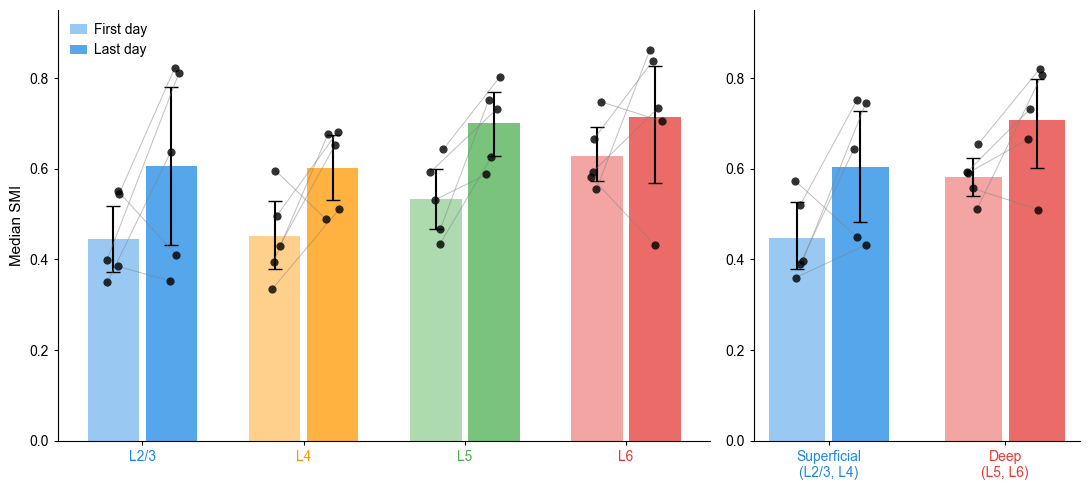

In [199]:
# Panel D — First vs Last day: 4-layer breakdown + Superficial vs Deep summary
# Uncertainty: 95% bootstrap CI on the mean; individual animal dots shown

N_BOOTSTRAP = 10_000
rng_bs = np.random.default_rng(0)

SUP_LAYERS  = ['L2/3', 'L4']
DEEP_LAYERS = ['L5',   'L6']
SUP_COLOR   = '#1E88E5'
DEEP_COLOR  = '#E53935'

def boot_ci(arr, n_boot=N_BOOTSTRAP, rng=rng_bs):
    if len(arr) < 2:
        return np.nan, np.nan
    means = [np.mean(rng.choice(arr, size=len(arr), replace=True)) for _ in range(n_boot)]
    return np.percentile(means, [2.5, 97.5])

# ── Per-layer first/last ──────────────────────────────────────────────────────
first_vals = {l: [] for l in LAYER_ORDER}
last_vals  = {l: [] for l in LAYER_ORDER}

for animal in animals:
    animal_days = sorted(smi_by_animal[animal].keys())
    for layer in LAYER_ORDER:
        days_with_layer = [d for d in animal_days
                           if layer in smi_by_animal[animal].get(d, {})
                           and len(smi_by_animal[animal][d][layer]) > 0]
        if len(days_with_layer) < 2:
            continue
        fd, ld = days_with_layer[0], days_with_layer[-1]
        first_vals[layer].append(np.median(smi_by_animal[animal][fd][layer]))
        last_vals[layer].append(np.median(smi_by_animal[animal][ld][layer]))

layer_ci = {}
for layer in LAYER_ORDER:
    fv, lv = np.array(first_vals[layer]), np.array(last_vals[layer])
    layer_ci[layer] = {'first': boot_ci(fv), 'last': boot_ci(lv)}
    print(f'{layer}: n={len(fv)}  first={np.mean(fv):.3f} CI{layer_ci[layer]["first"]}  '
          f'last={np.mean(lv):.3f} CI{layer_ci[layer]["last"]}')

# ── Sup/Deep first/last ───────────────────────────────────────────────────────
sd_first = {'Sup': [], 'Deep': []}
sd_last  = {'Sup': [], 'Deep': []}

for animal in animals:
    animal_days = sorted(smi_by_animal[animal].keys())
    for grp, layers in [('Sup', SUP_LAYERS), ('Deep', DEEP_LAYERS)]:
        days_with_grp = [d for d in animal_days
                         if all(l in smi_by_animal[animal].get(d, {}) for l in layers)]
        if len(days_with_grp) < 2:
            continue
        fd, ld = days_with_grp[0], days_with_grp[-1]
        sd_first[grp].append(np.mean([np.median(smi_by_animal[animal][fd][l]) for l in layers]))
        sd_last[grp].append( np.mean([np.median(smi_by_animal[animal][ld][l]) for l in layers]))

sd_ci = {}
for grp in ('Sup', 'Deep'):
    fv, lv = np.array(sd_first[grp]), np.array(sd_last[grp])
    sd_ci[grp] = {'first': boot_ci(fv), 'last': boot_ci(lv)}
    print(f'{grp}: n={len(fv)}  first={np.mean(fv):.3f}  last={np.mean(lv):.3f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig_d, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5),
                                   gridspec_kw={'width_ratios': [2, 1]})
bw, offset = 0.32, 0.18
rng = np.random.default_rng(42)

def plot_first_last(ax, x_pos, fv, lv, ci_f, ci_l, color, label_first=None, label_last=None):
    fv, lv = np.array(fv), np.array(lv)
    mean_f, mean_l = np.mean(fv), np.mean(lv)

    # Bars
    ax.bar(x_pos - offset, mean_f, width=bw, color=color, alpha=0.45, zorder=2,
           label=label_first)
    ax.bar(x_pos + offset, mean_l, width=bw, color=color, alpha=0.75, zorder=2,
           label=label_last)

    # Bootstrap CI error bars
    for xp, mean_g, (ci_lo, ci_hi) in [(x_pos-offset, mean_f, ci_f),
                                         (x_pos+offset, mean_l, ci_l)]:
        if not np.isnan(ci_lo):
            ci_err = np.array([[mean_g - ci_lo], [ci_hi - mean_g]])
            ax.errorbar(xp, mean_g, yerr=ci_err,
                        fmt='none', color='black', capsize=5, lw=1.5, zorder=3)

    # Individual animal dots (paired lines)
    for fval, lval in zip(fv, lv):
        jf = rng.uniform(-0.05, 0.05)
        jl = rng.uniform(-0.05, 0.05)
        ax.plot([x_pos-offset+jf, x_pos+offset+jl], [fval, lval],
                color='gray', lw=0.7, alpha=0.5, zorder=3)
        ax.scatter(x_pos-offset+jf, fval, color='black', s=35, alpha=0.8, zorder=4, linewidths=0)
        ax.scatter(x_pos+offset+jl, lval, color='black', s=35, alpha=0.8, zorder=4, linewidths=0)

# Left: 4 layers
x = np.arange(len(LAYER_ORDER))
for i, layer in enumerate(LAYER_ORDER):
    c  = LAYER_COLORS[layer]
    ci = layer_ci[layer]
    plot_first_last(ax1, x[i], first_vals[layer], last_vals[layer],
                    ci['first'], ci['last'], c,
                    label_first='First day' if i == 0 else None,
                    label_last='Last day'   if i == 0 else None)

ax1.set_xticks(x)
ax1.set_xticklabels(LAYER_ORDER, fontsize=12)
for tick, layer in zip(ax1.get_xticklabels(), LAYER_ORDER):
    tick.set_color(LAYER_COLORS[layer])
ax1.set_ylabel('Median SMI', fontsize=11)
ax1.set_ylim(0, 0.95);  ax1.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
ax1.tick_params(labelsize=10, length=3, width=0.8)
ax1.legend(fontsize=10, frameon=False, loc='upper left',
           handlelength=1.2, handletextpad=0.5)
ax1.spines[['top','right']].set_visible(False)
ax1.set_axisbelow(True)

# Right: Sup vs Deep
x2 = np.arange(2)
for i, (grp, c) in enumerate(zip(['Sup', 'Deep'], [SUP_COLOR, DEEP_COLOR])):
    ci = sd_ci[grp]
    plot_first_last(ax2, x2[i], sd_first[grp], sd_last[grp],
                    ci['first'], ci['last'], c)

ax2.set_xticks(x2)
ax2.set_xticklabels(['Superficial\n(L2/3, L4)', 'Deep\n(L5, L6)'], fontsize=11)
for tick, c in zip(ax2.get_xticklabels(), [SUP_COLOR, DEEP_COLOR]):
    tick.set_color(c)
ax2.set_ylim(0, 0.95);  ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
ax2.tick_params(labelsize=10, length=3, width=0.8)
ax2.spines[['top','right']].set_visible(False)
ax2.set_axisbelow(True)

plt.tight_layout()
for ext in ('.svg', '.png'):
    out = os.path.join(OUTPUT_DIR, f'figure3_panel_D_first_vs_last{ext}')
    fig_d.savefig(out, dpi=300, bbox_inches='tight', format=ext.lstrip('.'))
    print(f'Saved: {out}')
plt.show()

L2/3: n=5  mean=0.161  95% CI [-0.031, 0.336]  includes 0
L4: n=5  mean=0.152  95% CI [0.016, 0.246]  excludes 0 ✓
L5: n=5  mean=0.167  95% CI [0.102, 0.238]  excludes 0 ✓
L6: n=5  mean=0.085  95% CI [-0.058, 0.220]  includes 0
Sup: n=5  mean=0.156  95% CI [-0.009, 0.287]  includes 0
Deep: n=5  mean=0.126  95% CI [0.026, 0.226]  excludes 0 ✓
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\labmeeting_260420\output\panel_E_SMI_gain.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\labmeeting_260420\output\panel_E_SMI_gain.png


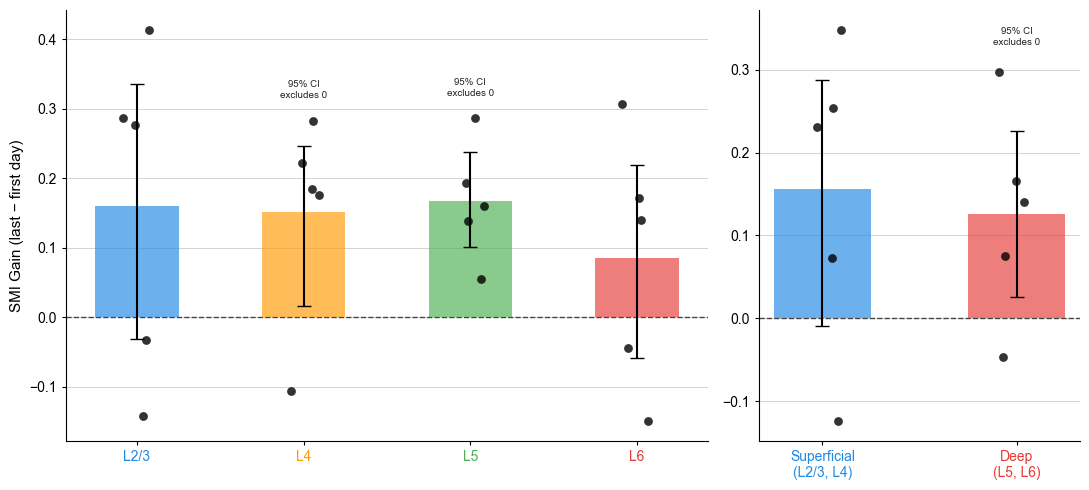

In [200]:
# Panel E — SMI Gain (last − first day): 4-layer breakdown + Sup vs Deep summary
# Uncertainty: 95% bootstrap CI; individual animal dots shown

N_BOOTSTRAP = 10_000
rng_bs = np.random.default_rng(0)

SUP_LAYERS  = ['L2/3', 'L4']
DEEP_LAYERS = ['L5',   'L6']
SUP_COLOR   = '#1E88E5'
DEEP_COLOR  = '#E53935'

def boot_ci(arr, n_boot=N_BOOTSTRAP, rng=rng_bs):
    if len(arr) < 2:
        return np.nan, np.nan
    means = [np.mean(rng.choice(arr, size=len(arr), replace=True)) for _ in range(n_boot)]
    return np.percentile(means, [2.5, 97.5])

# ── Per-layer gains ───────────────────────────────────────────────────────────
gain_data = {l: {"gains": [], "animals": [], "days": []} for l in LAYER_ORDER}

for animal in animals:
    animal_days = sorted(smi_by_animal[animal].keys())
    for layer in LAYER_ORDER:
        days_with_layer = [d for d in animal_days
                           if layer in smi_by_animal[animal].get(d, {})
                           and len(smi_by_animal[animal][d][layer]) > 0]
        if len(days_with_layer) < 2:
            continue
        fd, ld = days_with_layer[0], days_with_layer[-1]
        gain = (np.median(smi_by_animal[animal][ld][layer])
              - np.median(smi_by_animal[animal][fd][layer]))
        gain_data[layer]["gains"].append(gain)
        gain_data[layer]["animals"].append(animal)
        gain_data[layer]["days"].append((fd, ld))

for layer in LAYER_ORDER:
    g = np.array(gain_data[layer]["gains"])
    ci = boot_ci(g)
    gain_data[layer]["ci"] = ci
    excludes = not np.isnan(ci[0]) and (ci[0] > 0 or ci[1] < 0)
    print(f'{layer}: n={len(g)}  mean={np.mean(g):.3f}  95% CI [{ci[0]:.3f}, {ci[1]:.3f}]'
          f'  {"excludes 0 ✓" if excludes else "includes 0"}')

# ── Sup/Deep gains ────────────────────────────────────────────────────────────
sd_gains = {'Sup': [], 'Deep': []}

for animal in animals:
    animal_days = sorted(smi_by_animal[animal].keys())
    for grp, layers in [('Sup', SUP_LAYERS), ('Deep', DEEP_LAYERS)]:
        days_with_grp = [d for d in animal_days
                         if all(l in smi_by_animal[animal].get(d, {}) for l in layers)]
        if len(days_with_grp) < 2:
            continue
        fd, ld = days_with_grp[0], days_with_grp[-1]
        gain = (np.mean([np.median(smi_by_animal[animal][ld][l]) for l in layers])
              - np.mean([np.median(smi_by_animal[animal][fd][l]) for l in layers]))
        sd_gains[grp].append(gain)

sd_ci = {}
for grp in ('Sup', 'Deep'):
    g = np.array(sd_gains[grp])
    ci = boot_ci(g)
    sd_ci[grp] = ci
    excludes = not np.isnan(ci[0]) and (ci[0] > 0 or ci[1] < 0)
    print(f'{grp}: n={len(g)}  mean={np.mean(g):.3f}  95% CI [{ci[0]:.3f}, {ci[1]:.3f}]'
          f'  {"excludes 0 ✓" if excludes else "includes 0"}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig_e, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5),
                                   gridspec_kw={'width_ratios': [2, 1]})
bw  = 0.5
rng = np.random.default_rng(42)

# Left: 4 layers
x = np.arange(len(LAYER_ORDER))
for i, layer in enumerate(LAYER_ORDER):
    c  = LAYER_COLORS[layer]
    g  = np.array(gain_data[layer]["gains"])
    if len(g) == 0: continue
    mean_g = np.mean(g)
    ci_lo, ci_hi = gain_data[layer]["ci"]
    ci_err = np.array([[mean_g - ci_lo], [ci_hi - mean_g]])

    ax1.bar(x[i], mean_g, width=bw, color=c, alpha=0.65, zorder=2)
    ax1.errorbar(x[i], mean_g, yerr=ci_err,
                 fmt='none', color='black', capsize=5, lw=1.5, zorder=3)
    jitter = rng.uniform(-0.10, 0.10, size=len(g))
    ax1.scatter(x[i] + jitter, g, color='black', s=40, alpha=0.8, zorder=4, linewidths=0)
    if not np.isnan(ci_lo) and (ci_lo > 0 or ci_hi < 0):
        y_top = max(np.max(g), ci_hi) + 0.03
        ax1.text(x[i], y_top, '95% CI\nexcludes 0', ha='center', va='bottom',
                 fontsize=7, color='#222', linespacing=1.3)

ax1.axhline(0, color='#444', lw=1.0, ls='--', zorder=1)
ax1.set_xticks(x)
ax1.set_xticklabels(LAYER_ORDER, fontsize=12)
for tick, layer in zip(ax1.get_xticklabels(), LAYER_ORDER):
    tick.set_color(LAYER_COLORS[layer])
ax1.set_ylabel('SMI Gain (last − first day)', fontsize=11)
ax1.tick_params(labelsize=10, length=3, width=0.8)
ax1.yaxis.grid(True, color='#CCC', lw=0.6, zorder=0)
ax1.set_axisbelow(True)
ax1.spines[['top','right']].set_visible(False)

# Right: Sup vs Deep
x2 = np.arange(2)
for i, (grp, c) in enumerate(zip(['Sup', 'Deep'], [SUP_COLOR, DEEP_COLOR])):
    g = np.array(sd_gains[grp])
    if len(g) == 0: continue
    mean_g = np.mean(g)
    ci_lo, ci_hi = sd_ci[grp]
    ci_err = np.array([[mean_g - ci_lo], [ci_hi - mean_g]])

    ax2.bar(x2[i], mean_g, width=bw, color=c, alpha=0.65, zorder=2)
    ax2.errorbar(x2[i], mean_g, yerr=ci_err,
                 fmt='none', color='black', capsize=5, lw=1.5, zorder=3)
    jitter = rng.uniform(-0.10, 0.10, size=len(g))
    ax2.scatter(x2[i] + jitter, g, color='black', s=40, alpha=0.8, zorder=4, linewidths=0)
    if not np.isnan(ci_lo) and (ci_lo > 0 or ci_hi < 0):
        y_top = max(np.max(g), ci_hi) + 0.03
        ax2.text(x2[i], y_top, '95% CI\nexcludes 0', ha='center', va='bottom',
                 fontsize=7, color='#222', linespacing=1.3)

ax2.axhline(0, color='#444', lw=1.0, ls='--', zorder=1)
ax2.set_xticks(x2)
ax2.set_xticklabels(['Superficial\n(L2/3, L4)', 'Deep\n(L5, L6)'], fontsize=11)
for tick, c in zip(ax2.get_xticklabels(), [SUP_COLOR, DEEP_COLOR]):
    tick.set_color(c)
ax2.tick_params(labelsize=10, length=3, width=0.8)
ax2.yaxis.grid(True, color='#CCC', lw=0.6, zorder=0)
ax2.set_axisbelow(True)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
for ext in ('.svg', '.png'):
    out = os.path.join(OUTPUT_DIR, f'panel_E_SMI_gain{ext}')
    fig_e.savefig(out, dpi=300, bbox_inches='tight', format=ext.lstrip('.'))
    print(f'Saved: {out}')
plt.show()